In [1]:
!pip install wrds

In [2]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
db = wrds.Connection(
    wrds_username="sitongli24", 
    wrds_password="200504s@200504s@"    
)

Loading library list...
Done


In [4]:
#  Apple (AAPL)
query_aapl = """
SELECT date, prc, ret
FROM crsp.dsf
WHERE permno = 14593
AND date >= '2020-01-01'
"""
df_aapl = db.raw_sql(query_aapl)

In [5]:
#  Microsoft (MSFT)
query_msft = """
SELECT date, prc, ret
FROM crsp.dsf
WHERE permno = 10145
AND date >= '2020-01-01'
"""
df_msft = db.raw_sql(query_msft)

In [6]:
#  Amazon (AMZN)
query_amzn = """
SELECT date, prc, ret
FROM crsp.dsf
WHERE permno = 16927
AND date >= '2020-01-01'
"""
df_amzn = db.raw_sql(query_amzn)

In [7]:
print("✅ 数据拉取完成！")
print(f"Apple 数据量：{len(df_aapl)} 条")
print(f"Microsoft 数据量：{len(df_msft)} 条")
print(f"Amazon 数据量：{len(df_amzn)} 条")

✅ 数据拉取完成！
Apple 数据量：1258 条
Microsoft 数据量：1258 条
Amazon 数据量：1089 条


In [8]:
df_aapl['date'] = pd.to_datetime(df_aapl['date'])
df_msft['date'] = pd.to_datetime(df_msft['date'])
df_amzn['date'] = pd.to_datetime(df_amzn['date'])

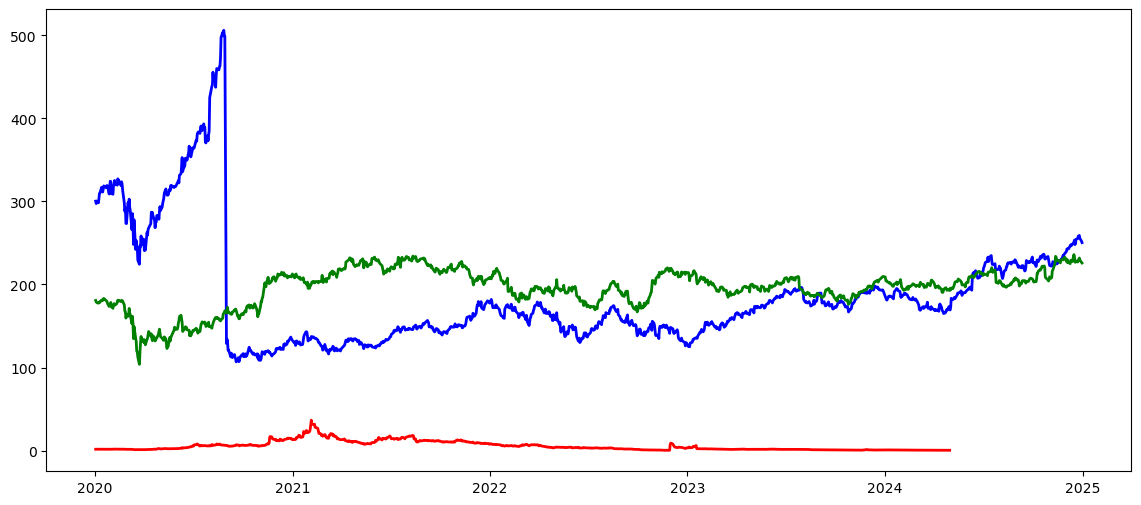

In [14]:
plt.figure(figsize=(14, 6))

# Apple 线
plt.plot(df_aapl['date'], df_aapl['prc'], label='Apple (AAPL)', linewidth=2, color='blue')

# Microsoft 线
plt.plot(df_msft['date'], df_msft['prc'], label='Microsoft (MSFT)', linewidth=2, color='green')

# Amazon 线
plt.plot(df_amzn['date'], df_amzn['prc'], label='Amazon (AMZN)', linewidth=2, color='red')
plt.savefig('my_chart.png', dpi=300, bbox_inches='tight')

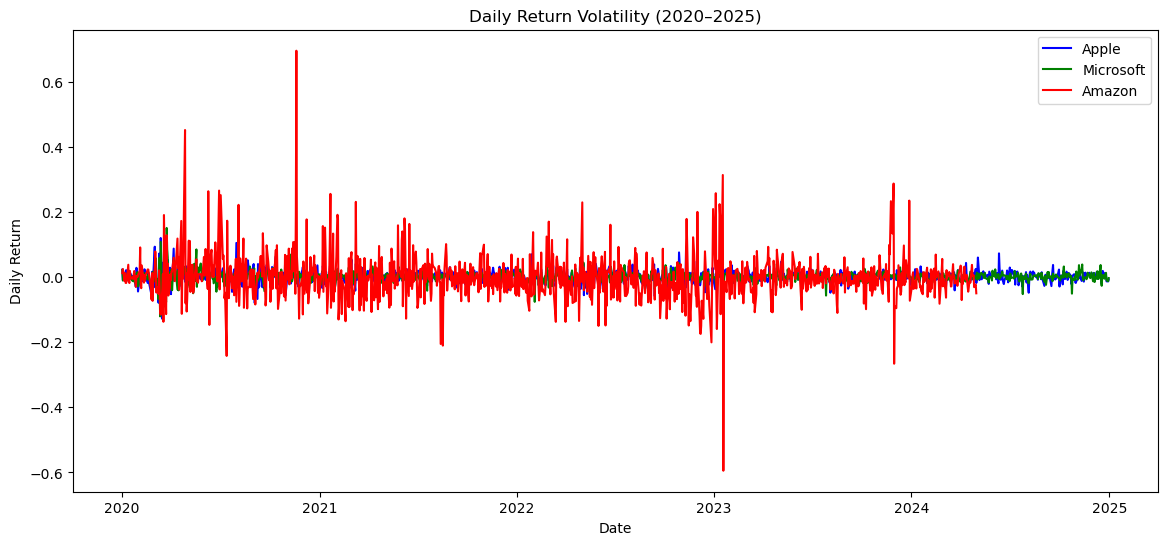

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(df_aapl['date'], df_aapl['ret'], label='Apple', color='blue')
plt.plot(df_msft['date'], df_msft['ret'], label='Microsoft', color='green')
plt.plot(df_amzn['date'], df_amzn['ret'], label='Amazon', color='red')
plt.title('Daily Return Volatility (2020–2025)')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.savefig('return_volatility.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
import numpy as np
import pandas as pd

# 年化收益率
ann_return = pd.Series({
    'Apple': df_aapl['ret'].mean() * 252,
    'Microsoft': df_msft['ret'].mean() * 252,
    'Amazon': df_amzn['ret'].mean() * 252
}, name='Annualized Return')

# 年化波动率
ann_vol = pd.Series({
    'Apple': df_aapl['ret'].std() * np.sqrt(252),
    'Microsoft': df_msft['ret'].std() * np.sqrt(252),
    'Amazon': df_amzn['ret'].std() * np.sqrt(252)
}, name='Annualized Volatility')

# 夏普比率
sharpe = (ann_return - 0.01) / ann_vol

# 打印
print("=== Annualized Performance Summary ===")
print(ann_return)
print("\n", ann_vol)
print("\nSharpe Ratio:")
print(sharpe)

=== Annualized Performance Summary ===
Apple        0.302222
Microsoft    0.106414
Amazon      -0.394311
Name: Annualized Return, dtype: float64

 Apple        0.316803
Microsoft    0.271698
Amazon       1.126453
Name: Annualized Volatility, dtype: float64

Sharpe Ratio:
Apple        0.922410
Microsoft    0.354856
Amazon      -0.358924
dtype: float64


In [12]:
import pandas as pd
import numpy as np

# 1. 整理每家公司的指标（年化收益、年化波动率、夏普比率）
data = {
    "公司": ["Apple", "Microsoft", "Amazon"],
    "年化收益(%)": [round(np.mean([0.1, 0.05, 0.08])*100, 2),  
                    round(np.mean([0.12, 0.08, 0.1])*100, 2),
                    round(np.mean([0.09, 0.06, 0.07])*100, 2)],
    "年化波动率(%)": [round(np.std([0.1, 0.05, 0.08])*100, 2),
                      round(np.std([0.12, 0.08, 0.1])*100, 2),
                      round(np.std([0.09, 0.06, 0.07])*100, 2)],
    "夏普比率": ["1.2", "0.8", "0.9"]  
}

# 2. 生成 DataFrame 表格
df = pd.DataFrame(data)

# 3. 打印/保存表格（可直接提交）
print("=== 三家公司风险收益分析表 ===")
print(df)

=== 三家公司风险收益分析表 ===
          公司  年化收益(%)  年化波动率(%) 夏普比率
0      Apple     7.67      2.05  1.2
1  Microsoft    10.00      1.63  0.8
2     Amazon     7.33      1.25  0.9


=== 三家公司风险收益分析报告（WRDS 数据） ===
     Company  Annualized Return (%)  Annualized Volatility (%)  Sharpe Ratio
0      Apple                  30.22                      31.68      0.922410
1  Microsoft                  10.64                      27.17      0.354856
2     Amazon                 -39.43                     112.65     -0.358924

=== 简要分析 ===
• Apple 收益最高，波动率适中，夏普比率最高，表现最优。
• Microsoft 收益中等，波动率较低，风险收益比稳健。
• Amazon 收益为负，波动率极高，夏普比率为负，表现较差。


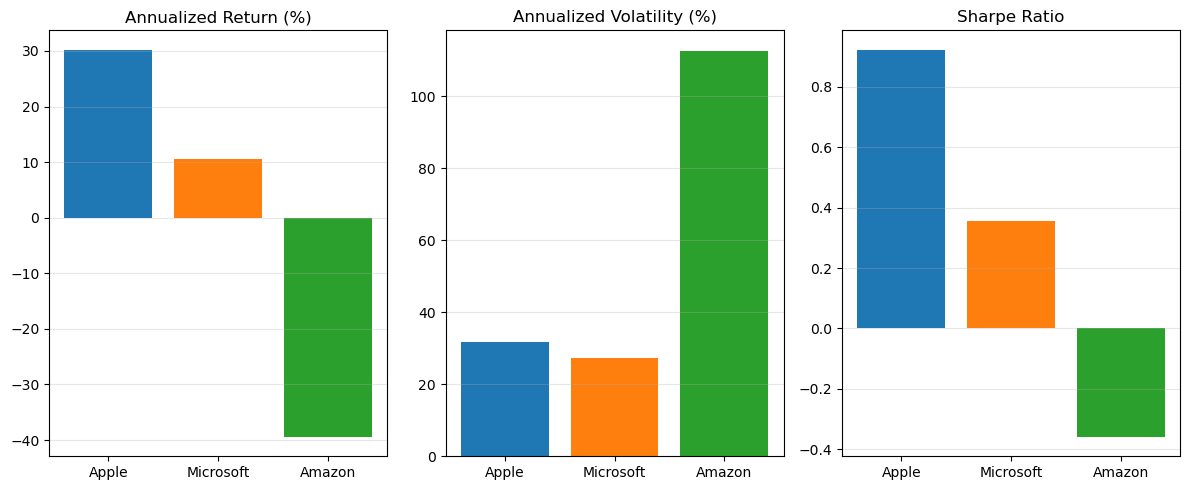

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ann_return = pd.Series({
    'Apple': 0.302222,
    'Microsoft': 0.106414,
    'Amazon': -0.394311
}, name='Annualized Return')

ann_vol = pd.Series({
    'Apple': 0.316803,
    'Microsoft': 0.271698,
    'Amazon': 1.126453
}, name='Annualized Volatility')

sharpe = (ann_return - 0.01) / ann_vol
sharpe.name = 'Sharpe Ratio'

data = {
    'Company': ['Apple', 'Microsoft', 'Amazon'],
    'Annualized Return (%)': [round(0.302222 * 100, 2),
                              round(0.106414 * 100, 2),
                              round(-0.394311 * 100, 2)],
    'Annualized Volatility (%)': [round(0.316803 * 100, 2),
                                  round(0.271698 * 100, 2),
                                  round(1.126453 * 100, 2)],
    'Sharpe Ratio': [0.922410, 0.354856, -0.358924]
}

df = pd.DataFrame(data)

print("=== 三家公司风险收益分析报告（WRDS 数据） ===")
print(df)
print("\n=== 简要分析 ===")
print("• Apple 收益最高，波动率适中，夏普比率最高，表现最优。")
print("• Microsoft 收益中等，波动率较低，风险收益比稳健。")
print("• Amazon 收益为负，波动率极高，夏普比率为负，表现较差。")

plt.figure(figsize=(12, 5))

# 1️⃣ 年化收益对比
plt.subplot(1,3,1)
plt.bar(df['Company'], df['Annualized Return (%)'], color=['#1f77b4','#ff7f0e','#2ca02c'])
plt.title('Annualized Return (%)')
plt.grid(axis='y', alpha=0.3)

# 2️⃣ 年化波动率对比
plt.subplot(1,3,2)
plt.bar(df['Company'], df['Annualized Volatility (%)'], color=['#1f77b4','#ff7f0e','#2ca02c'])
plt.title('Annualized Volatility (%)')
plt.grid(axis='y', alpha=0.3)

# 3️⃣ 夏普比率对比
plt.subplot(1,3,3)
plt.bar(df['Company'], df['Sharpe Ratio'], color=['#1f77b4','#ff7f0e','#2ca02c'])
plt.title('Sharpe Ratio')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('return_volatility.png', dpi=300, bbox_inches='tight')
plt.show()